In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Cấu hình giao diện biểu đồ
plt.style.use('ggplot')
sns.set(style="whitegrid", font_scale=1.1)

# Đường dẫn file
DATA_PATH = "data/my_gesture_landmarks.csv"
MODEL_PATH = "data/hand_gesture_mlp.h5"
SCALER_PATH = "data/scaler.pkl"
ENCODER_PATH = "data/label_encoder.pkl"

print(f"✅ TensorFlow Version: {tf.__version__}")

✅ TensorFlow Version: 2.20.0


✅ Đã nạp 8400 mẫu dữ liệu.


C:\Users\HOan\AppData\Local\Temp\ipykernel_26644\3501153006.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gesture_label', data=df, palette='viridis', order=df['gesture_label'].value_counts().index)
C:\Users\HOan\AppData\Local\Temp\ipykernel_26644\3501153006.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\VIET\Computer Vision\HandSign\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


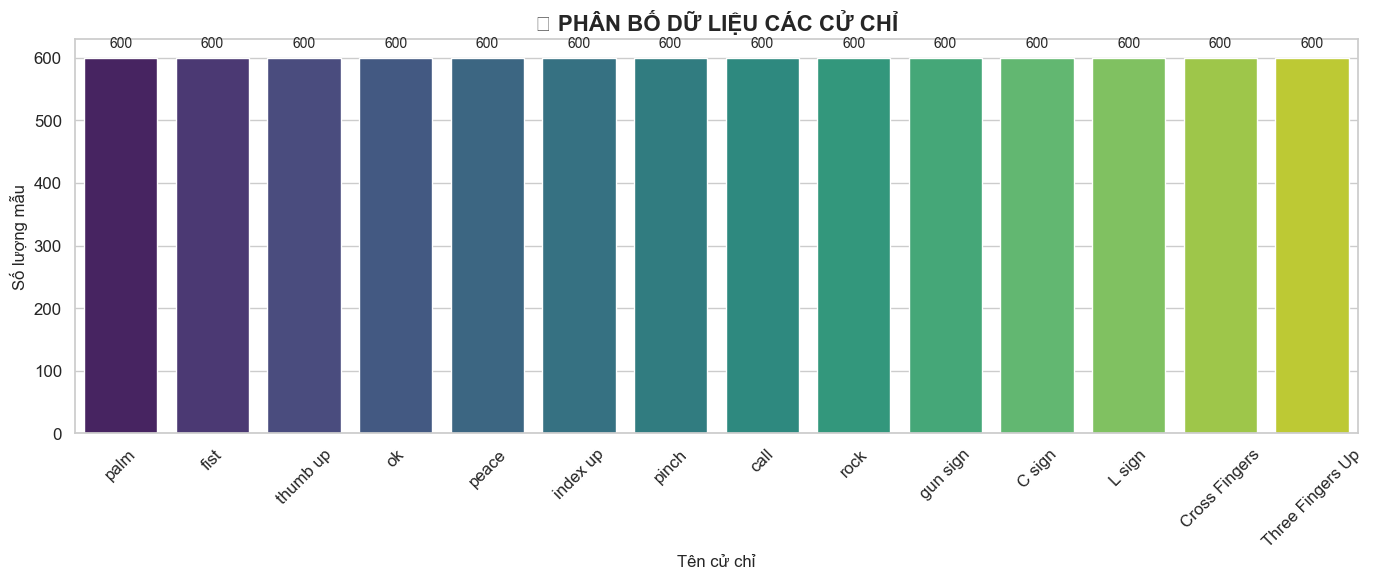

In [10]:
# 1. Đọc dữ liệu
if not os.path.exists(DATA_PATH):
    print(f"❌ Không tìm thấy file {DATA_PATH}. Hãy chạy collect_gesture.py trước!")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Đã nạp {len(df)} mẫu dữ liệu.")

    # 2. Vẽ biểu đồ phân bố số lượng mẫu
    plt.figure(figsize=(14, 6))
    ax = sns.countplot(x='gesture_label', data=df, palette='viridis', order=df['gesture_label'].value_counts().index)
    
    plt.title("📊 PHÂN BỐ DỮ LIỆU CÁC CỬ CHỈ", fontsize=16, fontweight='bold')
    plt.xlabel("Tên cử chỉ", fontsize=12)
    plt.ylabel("Số lượng mẫu", fontsize=12)
    plt.xticks(rotation=45)
    
    # Hiển thị số trên đầu cột
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)
    plt.tight_layout()
    plt.show()

In [11]:
# Tách Features và Label
X = df.drop(columns=['gesture_label']).values
y = df['gesture_label'].values

# 1. Mã hóa nhãn (String -> Số)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)
class_names = le.classes_

print(f"🏷️ Các nhãn đã học ({len(class_names)} loại): {class_names}")

# 2. Chia tập Train/Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# 3. Chuẩn hóa dữ liệu (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\n🔹 Train shape: {X_train.shape}")
print(f"🔹 Test shape: {X_test.shape}")

🏷️ Các nhãn đã học (14 loại): ['C sign' 'Cross Fingers' 'L sign' 'Three Fingers Up' 'call' 'fist'
 'gun sign' 'index up' 'ok' 'palm' 'peace' 'pinch' 'rock' 'thumb up']

🔹 Train shape: (6720, 63)
🔹 Test shape: (1680, 63)


In [12]:
# 1. Thiết kế mạng Neural (MLP)
model = Sequential([
    # Input: 63 features (21 landmarks * 3 coords)
    Dense(128, activation='relu', input_shape=(63,)),
    Dropout(0.3),  # Chống overfitting
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    
    # Output: Softmax cho bài toán phân loại nhiều lớp
    Dense(len(class_names), activation='softmax')
])

# 2. Compile
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# 3. Callbacks (Dừng sớm & Lưu model tốt nhất)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=0)

# 4. Train
print("🚀 Bắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)
print("✅ Huấn luyện hoàn tất!")

c:\VIET\Computer Vision\HandSign\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🚀 Bắt đầu huấn luyện...
Epoch 1/60
187/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2781 - loss: 2.2181

210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4570 - loss: 1.6547 - val_accuracy: 0.8167 - val_loss: 0.5809
Epoch 2/60
194/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7856 - loss: 0.6458

210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8341 - loss: 0.5087 - val_accuracy: 0.9560 - val_loss: 0.1743
Epoch 3/60
186/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9118 - loss: 0.2845

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9210 - loss: 0.2535 - val_accuracy: 0.9845 - val_loss: 0.0885
Epoch 4/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9435 - loss: 0.1720 - val_accuracy: 0.9827 - val_loss: 0.0713
Epoch 5/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9548 - loss: 0.1347 - val_accuracy: 0.9804 - val_loss: 0.0656
Epoch 6/60
202/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9705 - loss: 0.0964

...

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9772 - loss: 0.0695 - val_accuracy: 0.9899 - val_loss: 0.0374
Epoch 9/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9778 - loss: 0.0676 - val_accuracy: 0.9893 - val_loss: 0.0407
Epoch 10/60
202/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9816 - loss: 0.0631

210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0618 - val_accuracy: 0.9935 - val_loss: 0.0303
Epoch 11/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9836 - loss: 0.0529 - val_accuracy: 0.9911 - val_loss: 0.0357
Epoch 12/60
180/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9832 - loss: 0.0567

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9845 - loss: 0.0513 - val_accuracy: 0.9940 - val_loss: 0.0283
Epoch 13/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9871 - loss: 0.0431 - val_accuracy: 0.9940 - val_loss: 0.0275
Epoch 14/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9865 - loss: 0.0455 - val_accuracy: 0.9929 - val_loss: 0.0244
Epoch 15/60
189/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9892 - loss: 0.0349

210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0336 - val_accuracy: 0.9946 - val_loss: 0.0260
Epoch 16/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9878 - loss: 0.0386 - val_accuracy: 0.9935 - val_loss: 0.0310
Epoch 17/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9875 - loss: 0.0396 - val_accuracy: 0.9923 - val_loss: 0.0305
Epoch 18/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9915 - loss: 0.0284 - val_accuracy: 0.9946 - val_loss: 0.0283
Epoch 19/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9881 - loss: 0.0362 - val_accuracy: 0.9940 - val_loss: 0.0289
Epoch 20/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9871 - loss: 0.0467 - val_accuracy: 0.9905 - val_loss: 0.0379
Epoch 21/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9893 - loss: 0.0320 - val_accuracy: 0.9929 - val_loss: 0.0319
Epoch 22/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9885 - loss: 0.0409 - val_accuracy: 0.9940

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9918 - loss: 0.0272 - val_accuracy: 0.9958 - val_loss: 0.0275
Epoch 25/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9946 - loss: 0.0181 - val_accuracy: 0.9946 - val_loss: 0.0314
Epoch 26/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0255 - val_accuracy: 0.9899 - val_loss: 0.0371
Epoch 27/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9908 - loss: 0.0271 - val_accuracy: 0.9952 - val_loss: 0.0321
Epoch 28/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9924 - loss: 0.0261 - val_accuracy: 0.9923 - val_loss: 0.0400
Epoch 29/60
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9924 - loss: 0.0241 - val_accuracy: 0.9958 - val_loss: 0.0277
✅ Huấn luyện hoàn tất!


c:\VIET\Computer Vision\HandSign\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\VIET\Computer Vision\HandSign\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


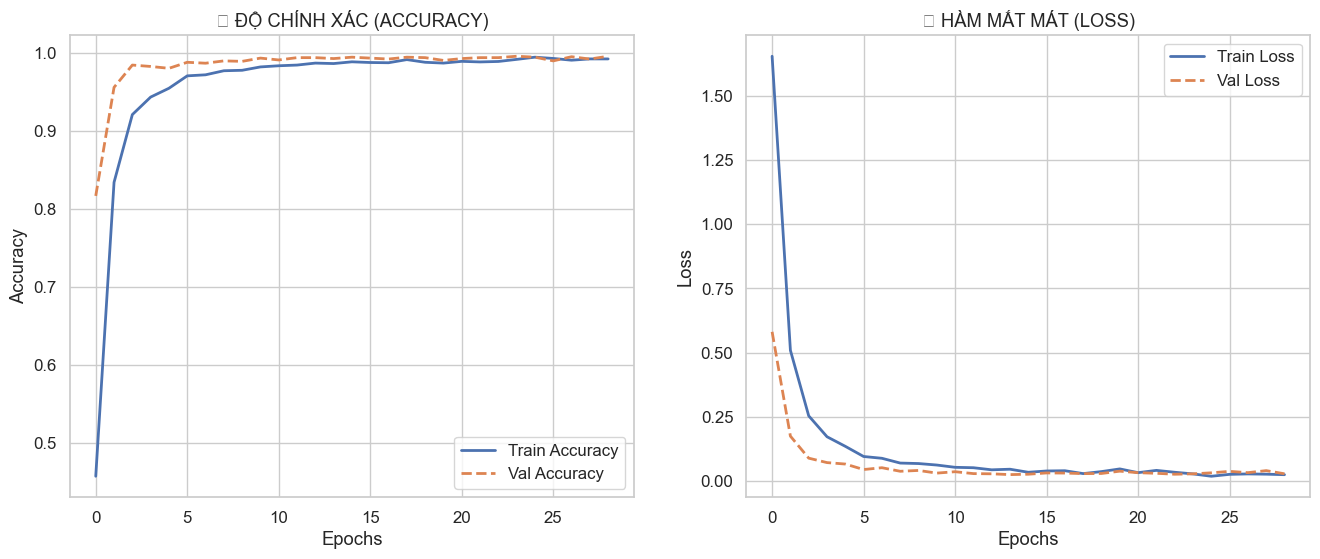

In [13]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Val Accuracy', linewidth=2, linestyle='--')
    plt.legend(loc='lower right')
    plt.title('📈 ĐỘ CHÍNH XÁC (ACCURACY)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Val Loss', linewidth=2, linestyle='--')
    plt.legend(loc='upper right')
    plt.title('📉 HÀM MẤT MÁT (LOSS)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.show()

plot_training_history(history)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\VIET\Computer Vision\HandSign\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


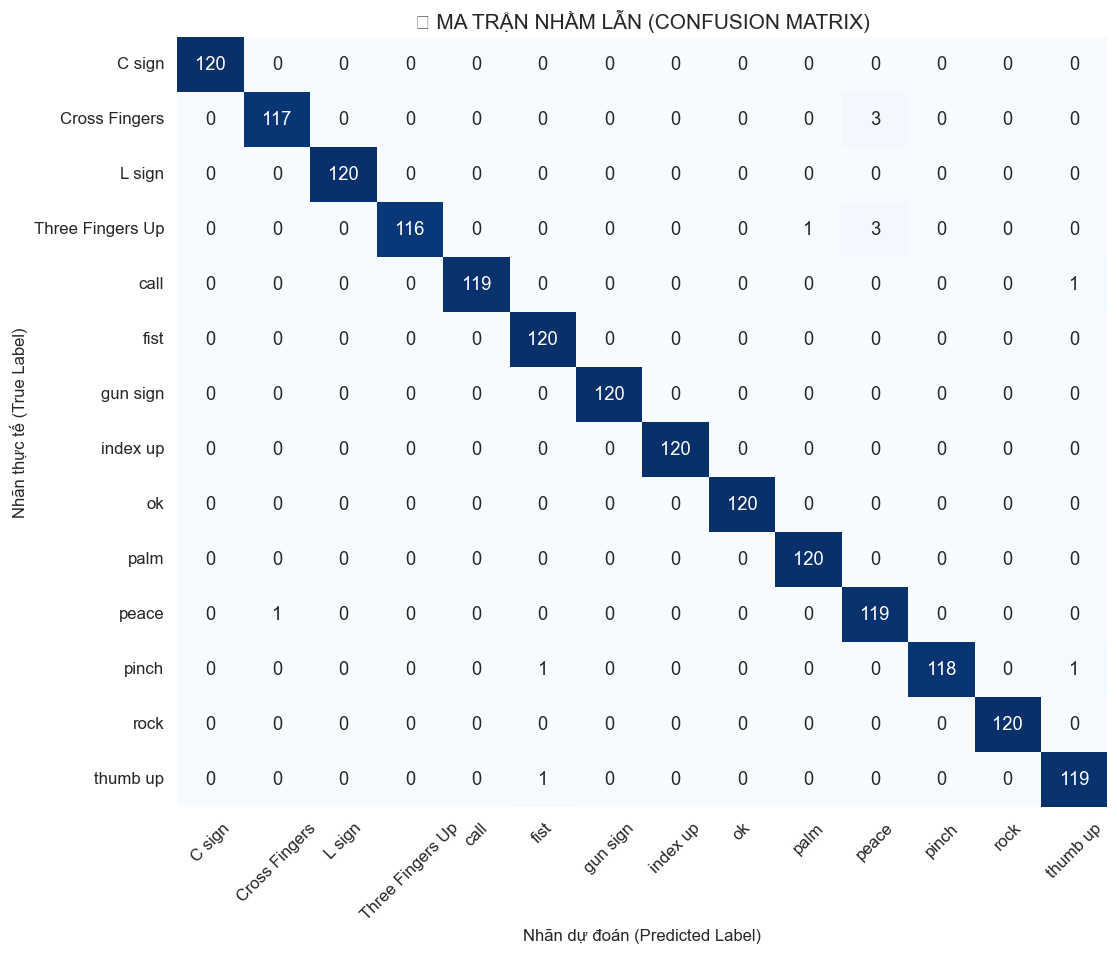

In [14]:
# Dự đoán trên tập Test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1) # Chuyển từ one-hot về nhãn số

# --- 1. MA TRẬN NHẦM LẪN (HEATMAP) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names, cbar=False)

plt.title('🔥 MA TRẬN NHẦM LẪN (CONFUSION MATRIX)', fontsize=15)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

C:\Users\HOan\AppData\Local\Temp\ipykernel_26644\4079518564.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gesture', y='F1-Score', data=df_metrics, palette='magma')
C:\Users\HOan\AppData\Local\Temp\ipykernel_26644\4079518564.py:35: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
c:\VIET\Computer Vision\HandSign\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


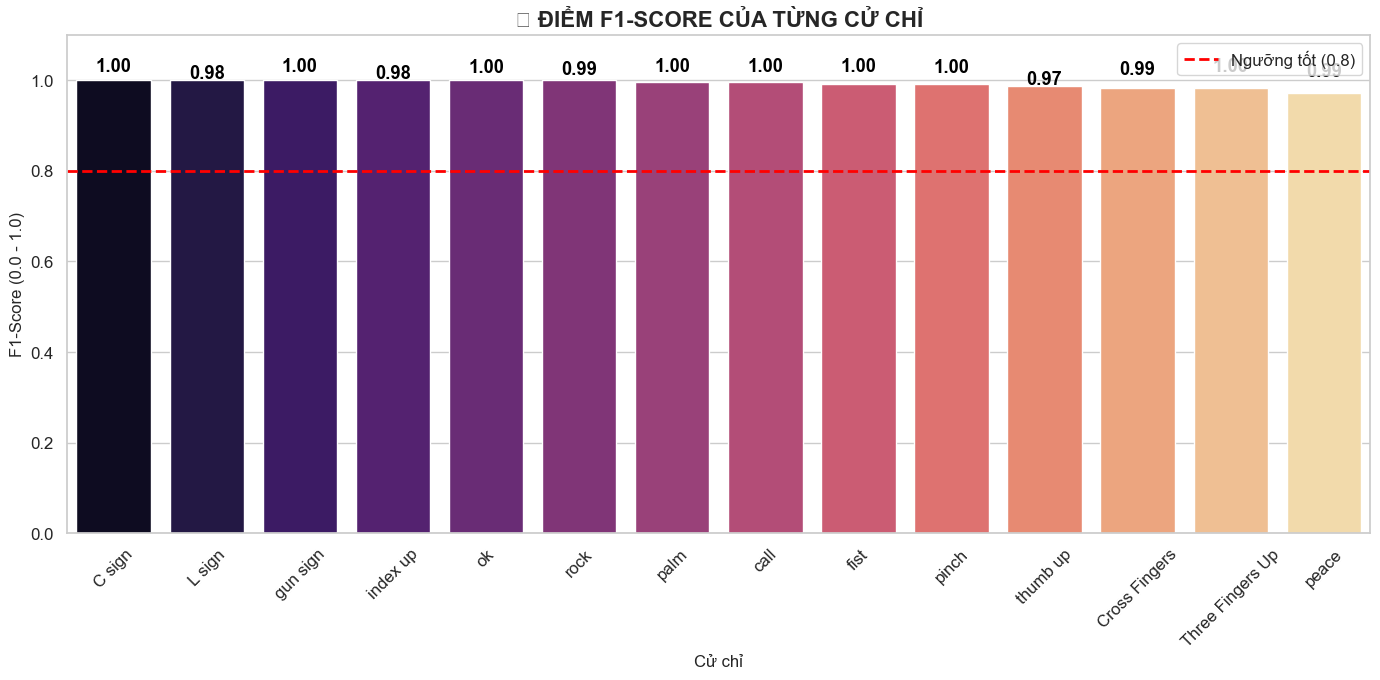


📋 BÁO CÁO PHÂN LOẠI CHI TIẾT:
                  precision    recall  f1-score   support

          C sign       1.00      1.00      1.00       120
   Cross Fingers       0.99      0.97      0.98       120
          L sign       1.00      1.00      1.00       120
Three Fingers Up       1.00      0.97      0.98       120
            call       1.00      0.99      1.00       120
            fist       0.98      1.00      0.99       120
        gun sign       1.00      1.00      1.00       120
        index up       1.00      1.00      1.00       120
              ok       1.00      1.00      1.00       120
            palm       0.99      1.00      1.00       120
           peace       0.95      0.99      0.97       120
           pinch       1.00      0.98      0.99       120
            rock       1.00      1.00      1.00       120
        thumb up       0.98      0.99      0.99       120

        accuracy                           0.99      1680
       macro avg       0.99      0.99  

In [15]:
# Tính Precision, Recall, F1 cho từng lớp
# average=None để tính cho từng lớp (class)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=range(len(class_names)))

# Tạo DataFrame để vẽ
df_metrics = pd.DataFrame({
    'Gesture': class_names,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall
})

# Sắp xếp theo F1-Score
df_metrics = df_metrics.sort_values(by='F1-Score', ascending=False)

# Vẽ biểu đồ F1-Score
plt.figure(figsize=(14, 7))
sns.barplot(x='Gesture', y='F1-Score', data=df_metrics, palette='magma')

# Đường kẻ tham chiếu 80% (mốc đánh giá tốt)
plt.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='Ngưỡng tốt (0.8)')
plt.legend()

plt.title('🏆 ĐIỂM F1-SCORE CỦA TỪNG CỬ CHỈ', fontsize=16, fontweight='bold')
plt.xlabel('Cử chỉ', fontsize=12)
plt.ylabel('F1-Score (0.0 - 1.0)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

# Hiển thị số trên cột - Sử dụng iloc hoặc iterrows thay vì itertuples
for index, row in df_metrics.iterrows():
    plt.text(index - df_metrics.index[0], row['F1-Score'] + 0.02, f'{row["F1-Score"]:.2f}', 
             ha='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# Báo cáo chi tiết dạng bảng (Classification Report)
print("\n📋 BÁO CÁO PHÂN LOẠI CHI TIẾT:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [16]:
# Lưu Scaler và Label Encoder (Bắt buộc để chạy App)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(le, ENCODER_PATH)

print("💾 Đã lưu thành công:")
print(f"   1. Model: {MODEL_PATH}")
print(f"   2. Scaler: {SCALER_PATH}")
print(f"   3. Encoder: {ENCODER_PATH}")

print("\n🎉 MỌI THỨ ĐÃ SẴN SÀNG! HÃY CHẠY FILE 'main_app.py' ĐỂ TEST.")

💾 Đã lưu thành công:
   1. Model: data/hand_gesture_mlp.h5
   2. Scaler: data/scaler.pkl
   3. Encoder: data/label_encoder.pkl

🎉 MỌI THỨ ĐÃ SẴN SÀNG! HÃY CHẠY FILE 'main_app.py' ĐỂ TEST.
